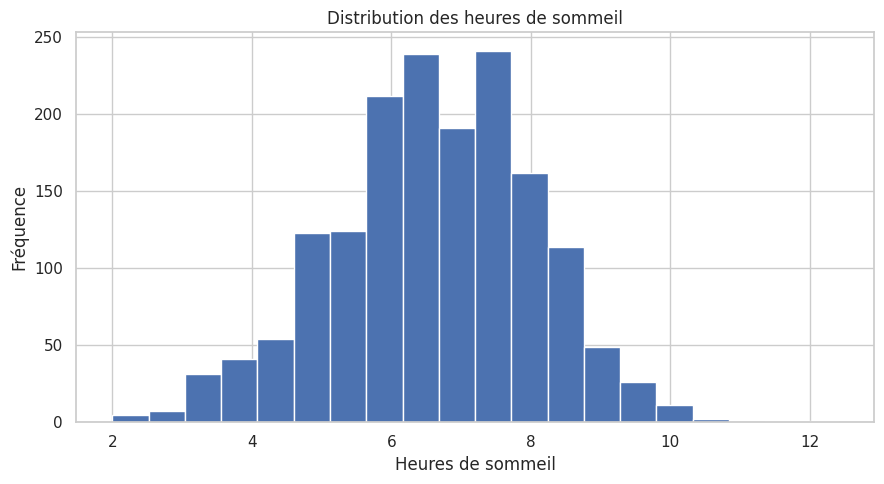

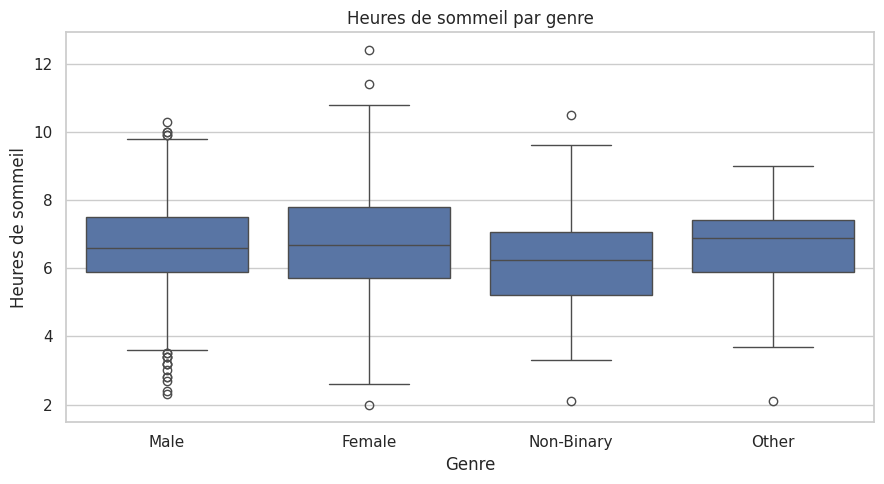

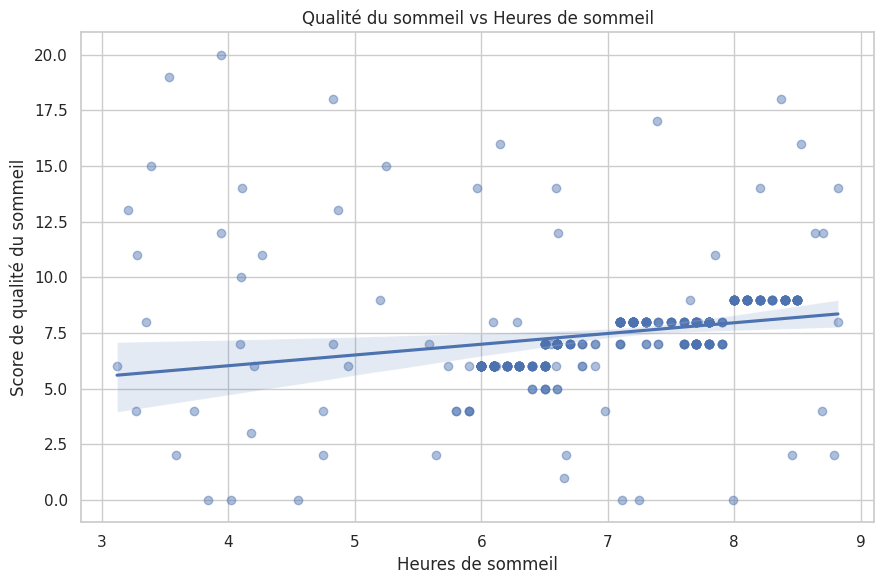

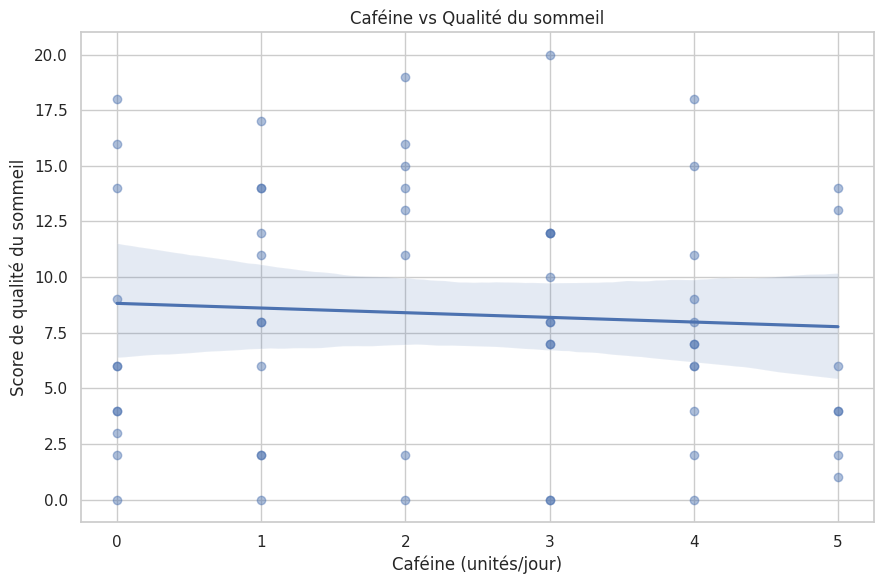

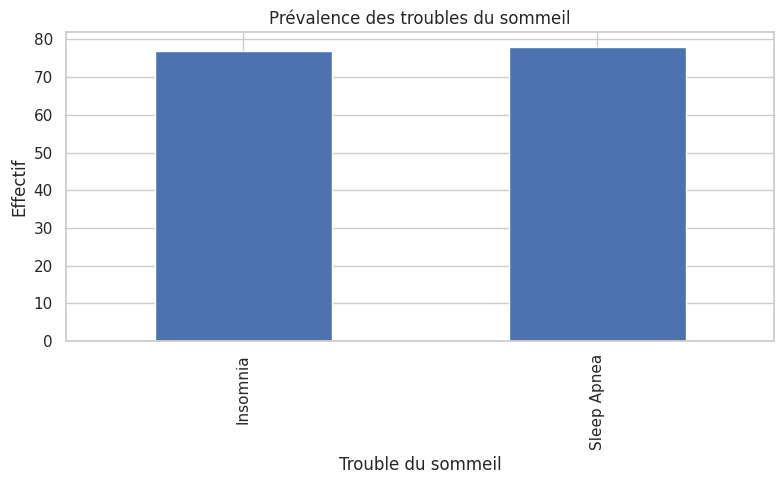

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


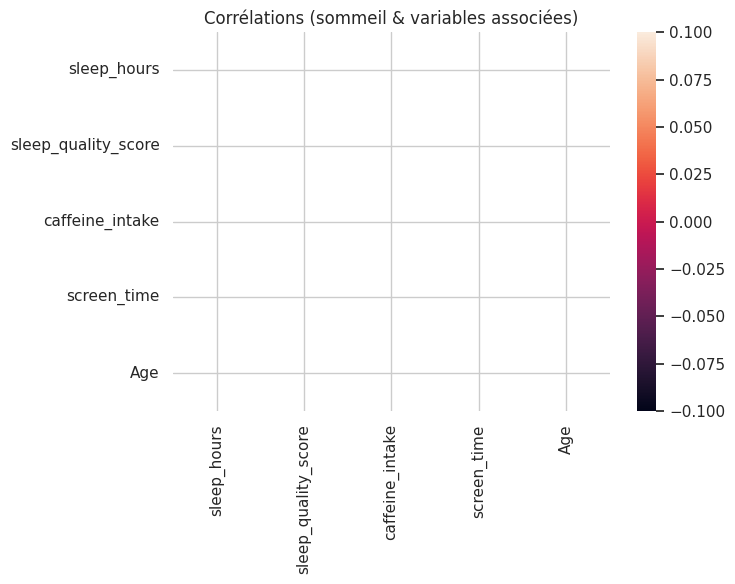

In [10]:
# sleep_viz_seaborn_matplotlib.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")


dem = pd.read_csv("dim_demographics.csv")
sleep = pd.read_csv("sleep_habits.csv")
sleep_fact = pd.read_csv("fact_sleep.csv")
mental = pd.read_csv("fact_mental_health.csv")


work = sleep.copy()
if "user_id" in work.columns and "participant_id" in dem.columns:
    work = work.merge(dem, left_on="user_id", right_on="participant_id", how="left")

for src in [sleep_fact, mental]:
    key = next((k for k in ["participant_id","user_id","id"] if k in work.columns and k in src.columns), None)
    if key:
        work = work.merge(src, on=key, how="left", suffixes=("", "_extra"))

# date column if present
date_col = next((c for c in work.columns if c.lower() in ["date","sleep_date","recorded_at","timestamp","datetime"]), None)
if date_col is not None:
    work[date_col] = pd.to_datetime(work[date_col], errors="coerce")

w
def has_cols(df, cols): return all(c in df.columns for c in cols)

def finish(fig_title=None):
    if fig_title: plt.title(fig_title)
    plt.tight_layout(); plt.show()

# ---------- 4) Plots ----------

# A) Matplotlib — Distribution des heures de sommeil
if "sleep_hours" in work.columns:
    plt.figure(figsize=(9,5))
    x = work["sleep_hours"].dropna()
    plt.hist(x, bins=20)
    plt.xlabel("Heures de sommeil"); plt.ylabel("Fréquence")
    finish("Distribution des heures de sommeil")

# B) Seaborn — Boxplot des heures par genre
if has_cols(work, ["sleep_hours","Gender"]):
    plt.figure(figsize=(9,5))
    sns.boxplot(data=work, x="Gender", y="sleep_hours")
    plt.xlabel("Genre"); plt.ylabel("Heures de sommeil")
    finish("Heures de sommeil par genre")

# C) Seaborn — Relation heures ↔ qualité du sommeil (régression)
if has_cols(work, ["sleep_hours","sleep_quality_score"]):
    plt.figure(figsize=(9,6))
    sns.regplot(data=work, x="sleep_hours", y="sleep_quality_score",
                scatter_kws={"alpha":0.45})
    plt.xlabel("Heures de sommeil"); plt.ylabel("Score de qualité du sommeil")
    finish("Qualité du sommeil vs Heures de sommeil")

# D) Seaborn — Caféine vs Qualité du sommeil (régression)
if has_cols(work, ["caffeine_intake","sleep_quality_score"]):
    plt.figure(figsize=(9,6))
    sns.regplot(data=work, x="caffeine_intake", y="sleep_quality_score",
                scatter_kws={"alpha":0.45})
    plt.xlabel("Caféine (unités/jour)"); plt.ylabel("Score de qualité du sommeil")
    finish("Caféine vs Qualité du sommeil")

# E) Matplotlib — Prévalence des troubles du sommeil
if "sleep_disorder" in work.columns:
    plt.figure(figsize=(8,5))
    counts = work["sleep_disorder"].dropna().astype(str).value_counts().sort_index()
    counts.plot(kind="bar")
    plt.xlabel("Trouble du sommeil"); plt.ylabel("Effectif")
    finish("Prévalence des troubles du sommeil")

# F) Seaborn — Corrélations (si assez de colonnes numériques pertinentes)
cand = [c for c in ["sleep_hours","sleep_quality_score","caffeine_intake","screen_time","Age"]
        if c in work.columns and pd.api.types.is_numeric_dtype(work[c])]
if len(cand) >= 3:
    plt.figure(figsize=(7.5,6))
    corr = work[cand].dropna().corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt=".2f")
    finish("Corrélations (sommeil & variables associées)")

# G) Seaborn — Qualité moyenne par jour de la semaine (si date)
if date_col and "sleep_quality_score" in work.columns:
    tmp = work.dropna(subset=[date_col,"sleep_quality_score"]).copy()
    if not tmp.empty:
        tmp["dow"] = tmp[date_col].dt.day_name()  # Monday, Tuesday, ...
        order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
        plt.figure(figsize=(9,5))
        ax = sns.barplot(data=tmp, x="dow", y="sleep_quality_score", order=order, estimator=np.mean)
        ax.set_xlabel("Jour de la semaine"); ax.set_ylabel("Score de qualité (moy.)")
        finish("Qualité du sommeil moyenne par jour")

# H) Seaborn — Effet écran: temps d'écran par classe d'âge (si Age & screen_time)
if has_cols(work, ["Age","screen_time"]):
    tmp = work[["Age","screen_time"]].dropna().copy()
    if not tmp.empty:
        tmp["age_band"] = pd.cut(tmp["Age"], bins=[0,25,40,55,120], labels=["≤25","26–40","41–55","56+"])
        plt.figure(figsize=(9,5))
        sns.boxplot(data=tmp, x="age_band", y="screen_time")
        plt.xlabel("Tranche d'âge"); plt.ylabel("Temps d'écran (h/j)")
        finish("Temps d'écran par tranche d'âge")


To install a Python library, you typically use the `pip install` command in a code cell. If the library is not found by default, you might need to run it with a '!' prefix to execute it as a shell command.

In [ ]:
# Example: Install the 'requests' library
!pip install requests

# After installation, you can import and use the library
import requests

print("'requests' library installed and imported successfully!")